
## Machine Learning Approaches for Early Identification of High-Risk Pregnancies in Rural Tanzania



### Overview

This project applies machine learning classification techniques to clinical data collected from pregnant women in rural Tanzania, with the goal of building a reliable model for **early identification of high-risk pregnancies** to support timely medical intervention and reduce maternal mortality.

Tanzania has one of the highest maternal mortality rates in Africa, with approximately 524 maternal deaths per 100,000 live births . Many of these deaths are preventable with early risk identification and appropriate clinical intervention especially critical in rural areas where access to specialist obstetric care is limited.

### Dataset

The **Dataset for Maternal Health Risks Stratification (MHRS) in Tanzania** was published by Mwifunyi et al. 2025. It contains 8,817 records of pregnant women attending primary health facilities across five rural districts in Tanzania


Data was collected between May 2024 and March 2025 through IoT-enabled medical systems at community health facilities. The dataset has 683 columns covering  lifestyle factors,demographics,  medical history, obstetric history,  clinical measurements across up to 8 antenatal visits, delivery outcomes, and postnatal follow-up. The target variable `Risk` classifies each pregnancy as high or low risk.


## 1. Import Libraries and Load Data

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Scikit-learn: Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Scikit-learn: Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn: Evaluation
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score, roc_auc_score,
                             ConfusionMatrixDisplay, roc_curve)




### Load the Dataset




In [3]:
# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/Mercylina01/Kuteesa_Mercylina_Uganda_FinalProject/main/maternal_dataset_csv.csv', low_memory=False)

print(f"Dataset shape: {df.shape}")
print(f"Number of records: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nFirst 5 rows (selected columns):")
display_cols = ['age', 'no_pregnancy', 'height_cm', 'weight_kg', 'duration_of_pregnancy_weeks_',
                'hypertension', 'diabetes_mellitus', 'hiv', 'blood_pressure_v1', 
                'hemoglobin_check_result_v1', 'Risk']
df[display_cols].head()


Dataset shape: (8817, 683)
Number of records: 8,817
Number of columns: 683

First 5 rows (selected columns):


,age,no_pregnancy,height_cm,weight_kg,duration_of_pregnancy_weeks_,hypertension,diabetes_mellitus,hiv,blood_pressure_v1,hemoglobin_check_result_v1,Risk
0,18,1,132.0,54,19,no,no,no,119/65,11.0,high
1,18,3,149.0,54,38,no,no,no,104/68,10.3,high
2,24,1,142.0,53,20,no,no,no,104/68,10.3,high
3,18,3,159.0,62,21,no,no,no,125/65,8.6,high
4,20,1,132.0,57,30,no,no,no,NaN,NaN,low


## 2. Exploratory Data Analysis (EDA)

The raw dataset has **683 columns** spanning multiple antenatal visits (v1–v8) and postnatal follow-ups.

### 2.1 Data Quality Overview


In [4]:
# Data types summary
print("DATA TYPES SUMMARY")

print(df.dtypes.value_counts())

print(f"\nTotal missing values: {df.isnull().sum().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Target variable

print("RISK CLASS DISTRIBUTION")

print(df['Risk'].value_counts())
print(f"\nPercentages:")
print((df['Risk'].value_counts(normalize=True) * 100).round(1))


DATA TYPES SUMMARY
object     627
float64     42
int64       14
Name: count, dtype: int64

Total missing values: 3,694,927
Duplicate rows: 0
RISK CLASS DISTRIBUTION
Risk
high    5510
low     3307
Name: count, dtype: int64

Percentages:
Risk
high    62.5
low     37.5
Name: proportion, dtype: float64


### 2.2 Target Variable Distribution




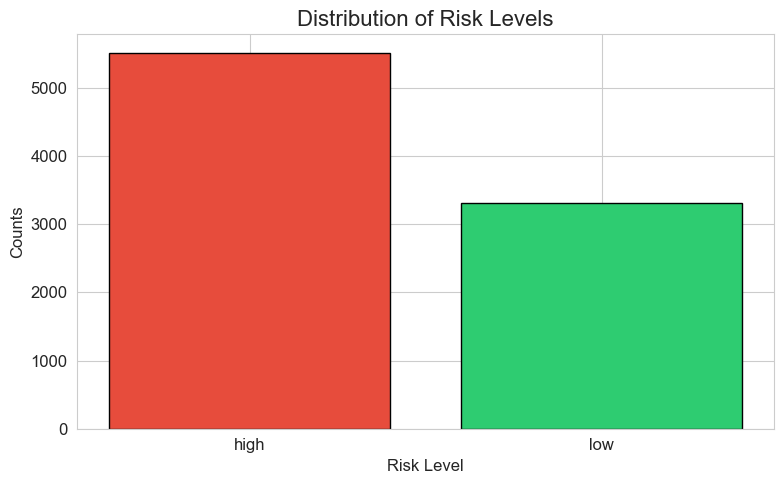

In [5]:

# Risk levels
risk_counts = df['Risk'].value_counts() 
labels = risk_counts.index.tolist()
values = risk_counts.values
colors = ['#e74c3c', '#2ecc71']

#Bar chart  
plt.figure(figsize=(8, 5))
bars = plt.bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='black')
plt.title('Distribution of Risk Levels', fontsize=16)
plt.xlabel('Risk Level')
plt.ylabel('Counts')
plt.tight_layout()
plt.show()

### 2.3 Demographic Distributions




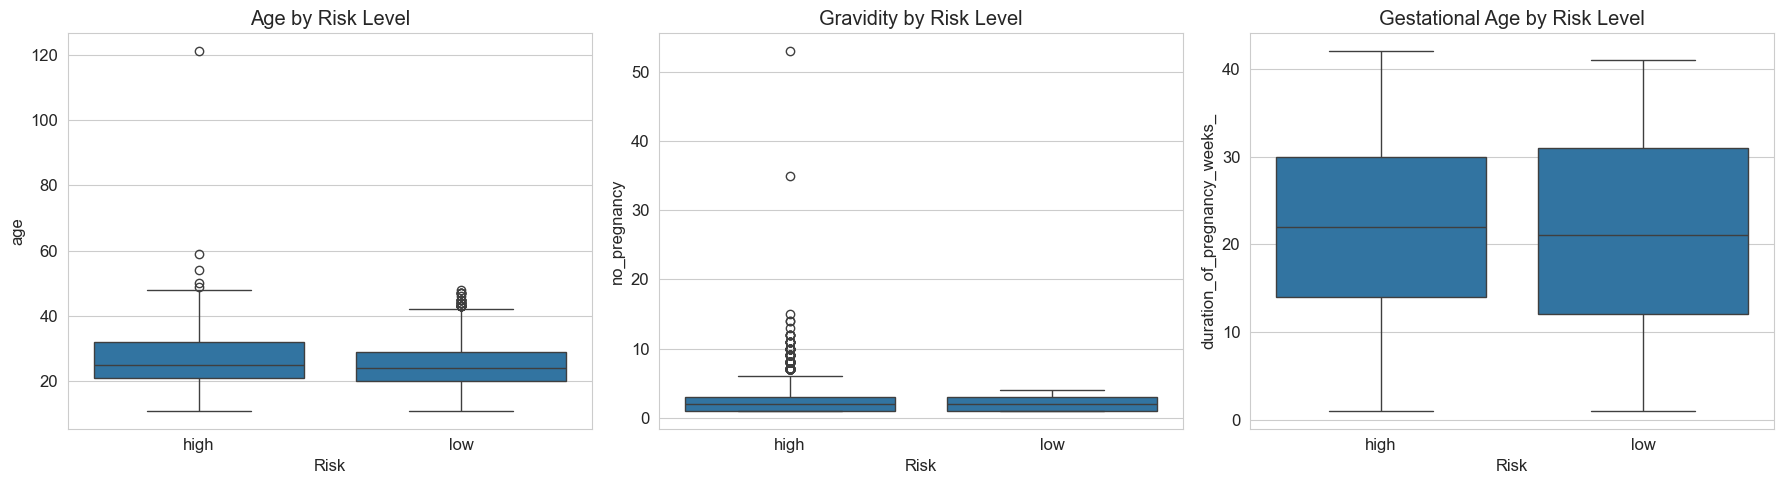

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='Risk', y='age',  ax=axes[0])
axes[0].set_title('Age by Risk Level')

sns.boxplot(data=df, x='Risk', y='no_pregnancy',  ax=axes[1])
axes[1].set_title('Gravidity by Risk Level')

sns.boxplot(data=df, x='Risk', y='duration_of_pregnancy_weeks_',  ax=axes[2])
axes[2].set_title('Gestational Age by Risk Level')

plt.tight_layout()
plt.show()

### 2.4 Clinical Measurements (Visit 1)



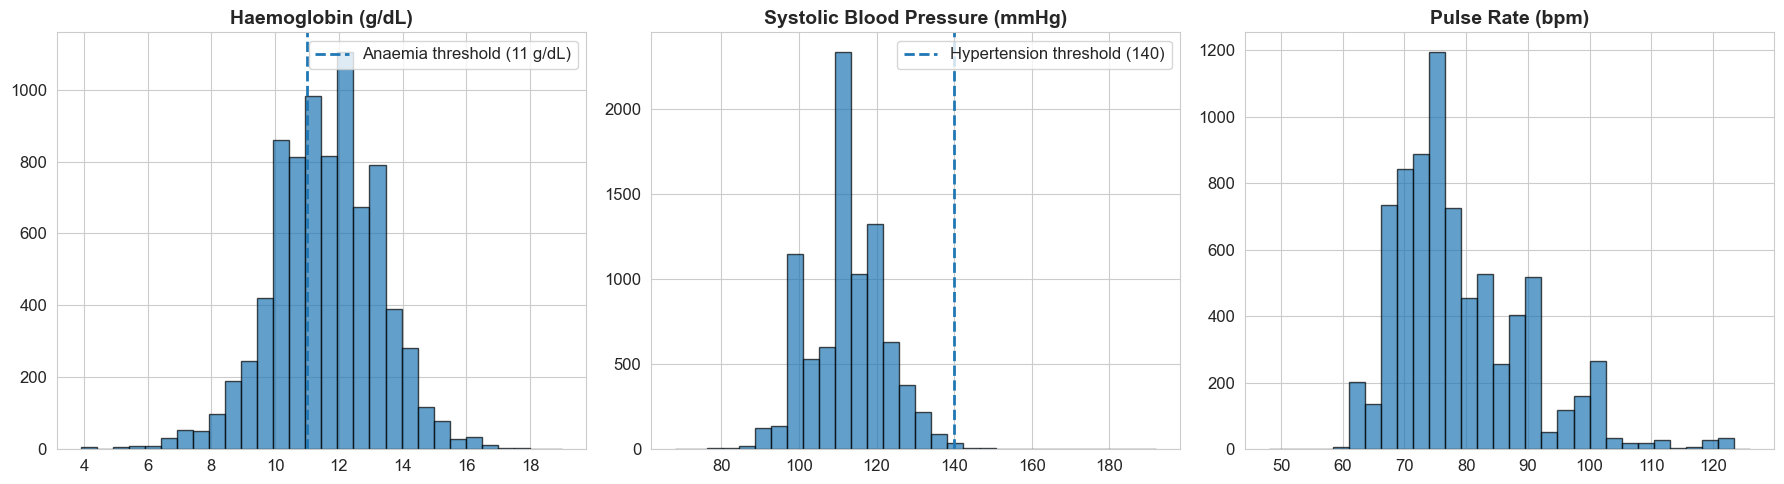

In [19]:

bp_split = df['blood_pressure_v1'].str.split('/', expand=True)
df['systolic_bp_v1'] = pd.to_numeric(bp_split[0], errors='coerce')
df['diastolic_bp_v1'] = pd.to_numeric(bp_split[1], errors='coerce')
df['pulse_rate_v1_num'] = pd.to_numeric(df['pulse_rate_v1'], errors='coerce')



def plot_hist(ax, data, title, xlim=None, threshold=None, threshold_label=None):
    data = data.dropna()
    
    if xlim:
        data = data[(data > xlim[0]) & (data < xlim[1])]
    
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    if threshold:
        ax.axvline(threshold, linestyle='--', linewidth=2, label=threshold_label)
        ax.legend()



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_hist(
    axes[0],
    df['hemoglobin_check_result_v1'],
    'Haemoglobin (g/dL)',
    xlim=(0, 20),
    threshold=11,
    threshold_label='Anaemia threshold (11 g/dL)'
)

plot_hist(
    axes[1],
    df['systolic_bp_v1'],
    'Systolic Blood Pressure (mmHg)',
    xlim=(60, 200),
    threshold=140,
    threshold_label='Hypertension threshold (140)'
)

plot_hist(
    axes[2],
    df['pulse_rate_v1_num'],
    'Pulse Rate (bpm)',
    xlim=(40, 130)
)

plt.tight_layout()
plt.show()

## 2.5 Feature Engineering & Data Preprocessing

In [25]:
# 1.Blood pressure
df_bp = df['blood_pressure_v1'].dropna().str.split('/', expand=True)
df.loc[df_bp.index, 'systolic_bp'] = pd.to_numeric(df_bp[0], errors='coerce')
df.loc[df_bp.index, 'diastolic_bp'] = pd.to_numeric(df_bp[1], errors='coerce')

# 2. Parse numeric vitals from Visit1
df['pulse_rate'] = pd.to_numeric(df['pulse_rate_v1'], errors='coerce')
df['body_temp'] = pd.to_numeric(df['body_temperature_v1'], errors='coerce')
df['weight_baseline'] = pd.to_numeric(df['weight_kg'], errors='coerce')

# 3. BMI calculation
df.loc[df['height_cm'] == 0, 'height_cm'] = np.nan
df['bmi'] = df['weight_baseline'] / ((df['height_cm'] / 100) ** 2)
# Cap extreme BMI values
df.loc[df['bmi'] > 60, 'bmi'] = np.nan
df.loc[df['bmi'] < 12, 'bmi'] = np.nan

# 4. Binary encoding 
binary_cols = [
    'vaginal_bleeding', 'nausea_and_vomiting', 'problems_in_current_pregnancy','heart_problems',
    'prior_caesarean_delivery', 'miscarriages_or_abortions', 'sexually_transmitted_diseases',
    'presence_of_hypertension_in_previous_pregnancies',
    'hypertension', 'diabetes_mellitus', 'gestational_diabetes',
    'hiv', 'tuberculosis','asthma',
    'sickle_cell_or_haematological_disorders',  'epilepsy',
    'smoking', 'use_of_drugs', 'intimate_partner_violence', 'twin_pregnancy'
]

for col in binary_cols:
    df[col + '_bin'] = (df[col] == 'yes').astype(int)

# 5. Alcohol use (has 3 categories)
df['alcohol_bin'] = (df['use_of_alcohol'] == 'yes').astype(int)

# 6. Encode target
df['risk_label'] = (df['Risk'] == 'high').astype(int)

feature_cols = [
    # Demographics
    'age', 'height_cm', 'weight_baseline', 'bmi',
    # Obstetric history
    'no_pregnancy', 'number_of_prior_deliveries',
    'number_of_prior_pregnancies_with_live_births',
    'number_of_prior_pregnancies_with_stillbirths',
    # Current pregnancy
    'duration_of_pregnancy_weeks_',
    'vaginal_bleeding_bin', 'nausea_and_vomiting_bin',
    'problems_in_current_pregnancy_bin', 'twin_pregnancy_bin',
    # Medical history
    'prior_caesarean_delivery_bin', 'miscarriages_or_abortions_bin',
    'presence_of_hypertension_in_previous_pregnancies_bin',
    'heart_problems_bin', 'hypertension_bin', 'diabetes_mellitus_bin',
    'gestational_diabetes_bin', 'hiv_bin', 'sexually_transmitted_diseases_bin',
    'tuberculosis_bin', 'sickle_cell_or_haematological_disorders_bin',
    'asthma_bin', 'epilepsy_bin',
    # Lifestyle
    'smoking_bin', 'use_of_drugs_bin', 'alcohol_bin',
    'intimate_partner_violence_bin',
    # Visit 1 clinical measurements
    'systolic_bp', 'diastolic_bp', 'pulse_rate', 'body_temp',
    'hemoglobin_check_result_v1', 'weight_kg_v1'
]

target_col = 'risk_label'

# Create modeling dataframe
df_model = df[feature_cols + [target_col]].copy()

print(f"Modeling dataset shape: {df_model.shape}")
print(f"\nMissing values per feature:")
missing = df_model.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))
print(f"\nTotal rows with any missing: {df_model.isnull().any(axis=1).sum()}")


Modeling dataset shape: (8817, 37)

Missing values per feature:
body_temp                     2643
pulse_rate                    1148
hemoglobin_check_result_v1     692
bmi                            452
weight_baseline                411
diastolic_bp                   160
systolic_bp                    160
weight_kg_v1                    55
height_cm                        3
dtype: int64

Total rows with any missing: 3280


### 3.0 Handling Missing Values

Using medium imputation to drop rows where critical features are entirely missing. This preserves the maximum number of observations while avoiding bias.


In [28]:
#  use median for continuous features

for col in feature_cols:
    if df_model[col].isnull().sum() > 0:
        median_val = df_model[col].median()
        df_model[col] = df_model[col].fillna(median_val)

#  outliers in specific 
df_model.loc[df_model['age'] > 55, 'age'] = 55
df_model.loc[df_model['hemoglobin_check_result_v1'] > 20, 'hemoglobin_check_result_v1'] = 20
df_model.loc[df_model['weight_kg_v1'] > 200, 'weight_kg_v1'] = df_model['weight_kg_v1'].median()
df_model.loc[df_model['no_pregnancy'] > 15, 'no_pregnancy'] = 15


assert df_model.isnull().sum().sum() == 0, "Still have missing values!"
assert not np.isinf(df_model[feature_cols].values).any(), "Still have Inf values!"

print(f"Missing values after imputation: {df_model.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(df_model[feature_cols].values).sum()}")
print(f"Final modeling dataset: {df_model.shape}")
print(f"\nTarget distribution:")
print(df_model[target_col].value_counts())
print(f"\nClass balance: {df_model[target_col].mean():.1%} high risk")

Missing values after imputation: 0
Infinite values: 0
Final modeling dataset: (8817, 37)

Target distribution:
risk_label
1    5510
0    3307
Name: count, dtype: int64

Class balance: 62.5% high risk


### 3.2 Feature Correlations
To show how each of the features is linked to a risk level.




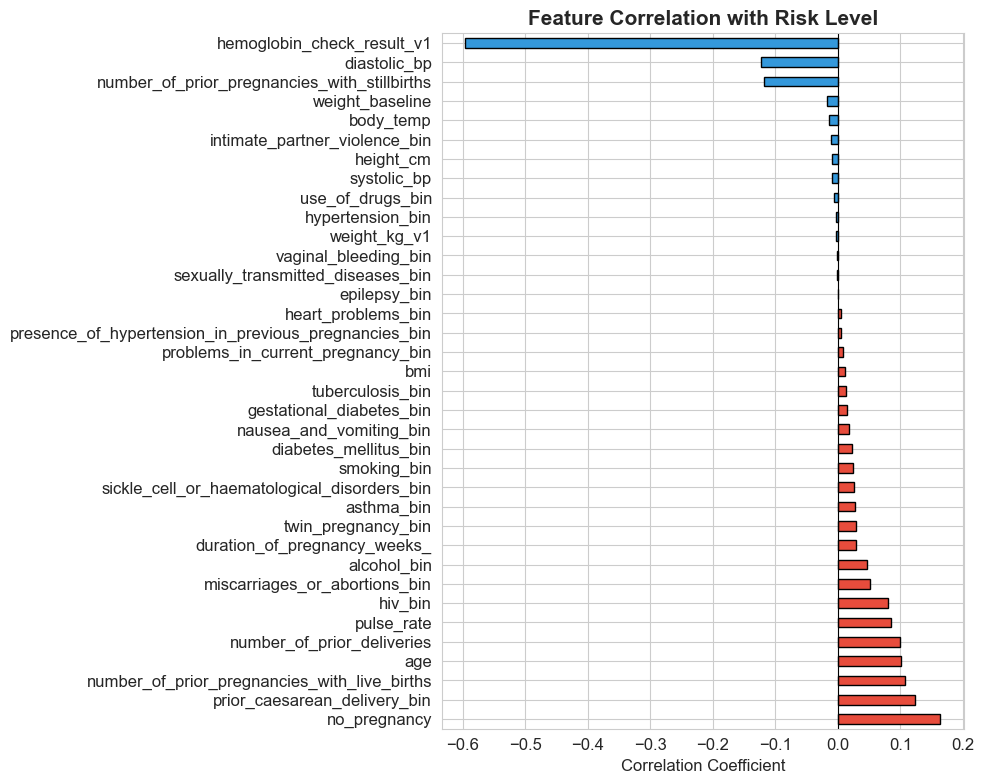

In [29]:
target_corr = df_model.corr()['risk_label'].drop('risk_label').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Feature Correlation with Risk Level', fontsize=15, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 4. Model Building

### 4.1 Train-Test Split and Feature Scaling
 Spliting the test and training data for model accuracy.

In [30]:
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set: 7,053 samples
Test set:     1,764 samples


### 4.2 Model Training & Comparison

Training **six different classification models** and evaluate each using 5-fold stratified cross-validation on the training set, then test on the held-out test set.


In [32]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, probability=True)
}

results = {}

for name, model in models.items():
    if name in ['Logistic Regression', 'KNN (k=5)', 'SVM (RBF)']:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train.values, X_test.values
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {'accuracy': acc, 'f1': f1, 'auc': auc, 'y_pred': y_pred, 'y_proba': y_proba}
    
    print(f"{name:<25} Accuracy: {acc:.4f}   F1: {f1:.5f}   AUC: {auc:.5f}")

Logistic Regression       Accuracy: 0.8537   F1: 0.88389   AUC: 0.92754
KNN (k=5)                 Accuracy: 0.7902   F1: 0.83136   AUC: 0.85452
Decision Tree             Accuracy: 0.8815   F1: 0.90522   AUC: 0.87351
Random Forest             Accuracy: 0.9121   F1: 0.92601   AUC: 0.95595
Gradient Boosting         Accuracy: 0.9150   F1: 0.92782   AUC: 0.95634
SVM (RBF)                 Accuracy: 0.8628   F1: 0.88879   AUC: 0.93234


### 4.3 Model Comparison Visualization
Evaluating multiple models to demostrate a superior perfomance in identifying the highest risk pregnancy.

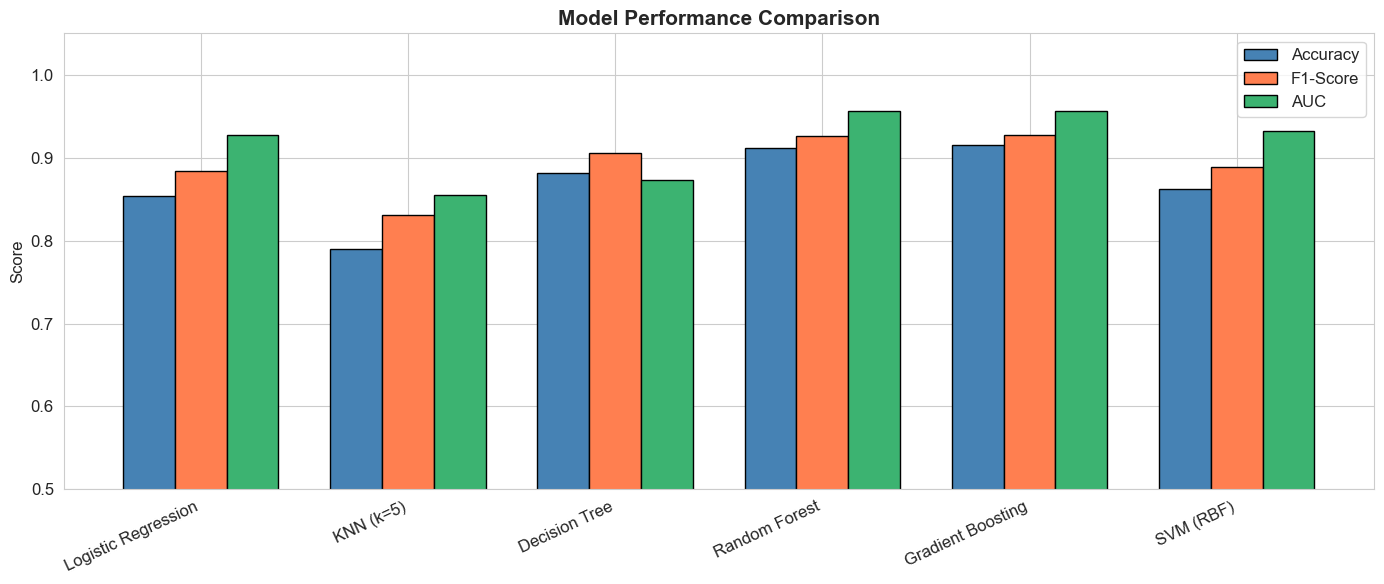

In [33]:
model_names = list(results.keys())
accs = [results[m]['accuracy'] for m in model_names]
f1s = [results[m]['f1'] for m in model_names]
aucs = [results[m]['auc'] for m in model_names]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(model_names))
width = 0.25

ax.bar(x - width, accs, width, label='Accuracy', color='steelblue', edgecolor='black')
ax.bar(x, f1s, width, label='F1-Score', color='coral', edgecolor='black')
ax.bar(x + width, aucs, width, label='AUC', color='mediumseagreen', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=25, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()

## 5 Detailed Analysis

Model selection using AUC and F1-score, then perform deeper evaluation.


In [36]:
# Select best model
best_model_name = max(results, key=lambda m: results[m]['auc'])
best_res = results[best_model_name]

print(f"Best model: {best_model_name}")
print(f"   Accuracy: {best_res['accuracy']:.4f}")
print(f"   F1-Score: {best_res['f1']:.4f}")
print(f"   AUC:      {best_res['auc']:.4f}")


Best model: Gradient Boosting
   Accuracy: 0.9150
   F1-Score: 0.9278
   AUC:      0.9563


### 5.1 Confusion Matrix

This show how many of many of each type of mistakes the model makes.

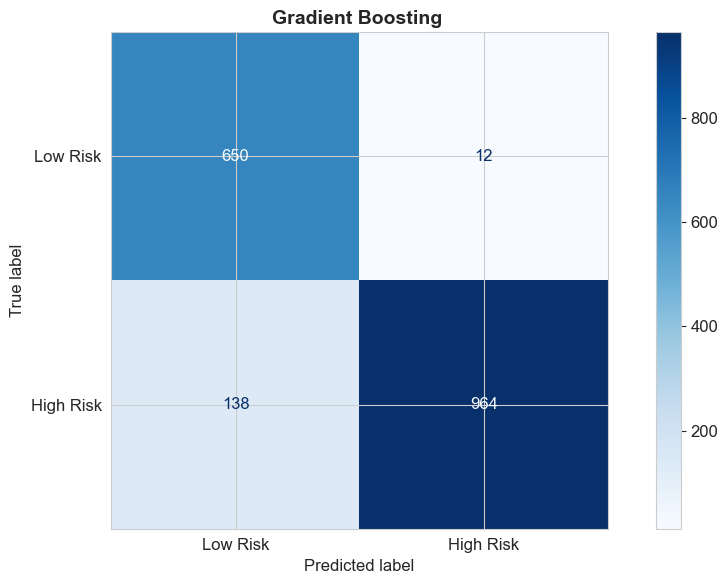

In [41]:
cm = confusion_matrix(y_test, best_res['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'{best_model_name} ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Classification Report

In [42]:
# Classification report
print(f"Classification Report — {best_model_name}")
print(classification_report(y_test, best_res['y_pred'], target_names=['Low Risk', 'High Risk']))


Classification Report — Gradient Boosting
              precision    recall  f1-score   support

    Low Risk       0.82      0.98      0.90       662
   High Risk       0.99      0.87      0.93      1102

    accuracy                           0.91      1764
   macro avg       0.91      0.93      0.91      1764
weighted avg       0.93      0.91      0.92      1764



### 5.3 Feature Importance
    This clearly identifies heamoglibin to be the strongest preditor with the highest risk pregancies among women in rural Tanzania.

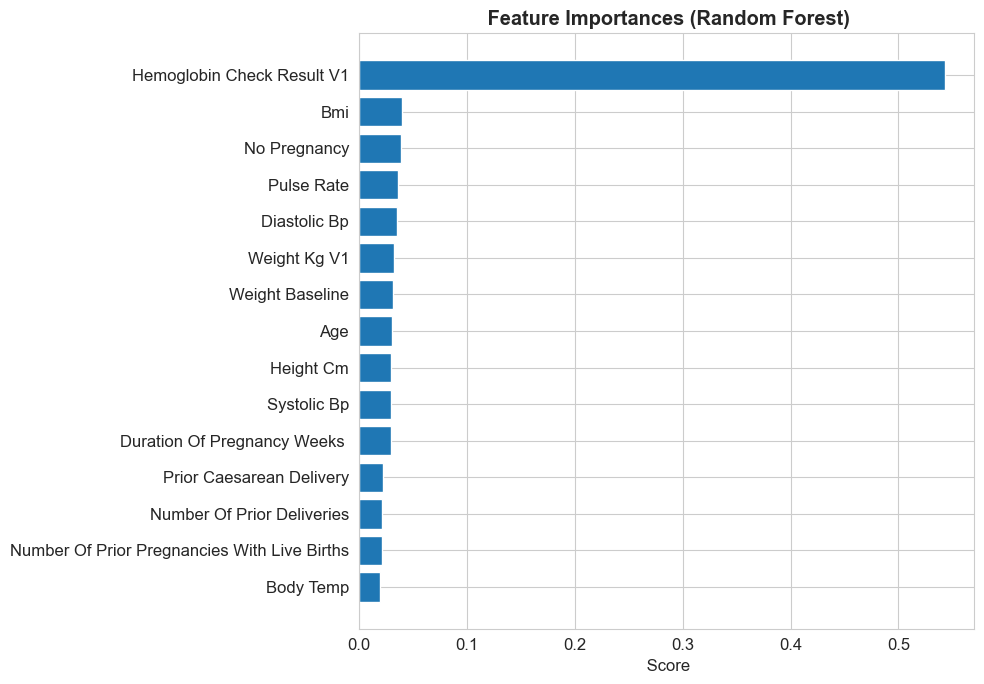

In [47]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train.values, y_train)

feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

top_n = 15
feat_top = feat_imp.tail(top_n)

plt.figure(figsize=(10, 7))
plt.barh(range(len(feat_top)), feat_top['Importance'])
plt.yticks(range(len(feat_top)), [f.replace('_bin','').replace('_',' ').title() for f in feat_top['Feature']])
plt.xlabel(' Score')
plt.title(' Feature Importances (Random Forest)',fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning

Optimize the Gradient Boosting Classifier using GridSearchCV.


In [50]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=3, scoring='roc_auc', n_jobs=-1
)

grid_search.fit(X_train.values, y_train)

y_pred_tuned = grid_search.predict(X_test.values)
y_proba_tuned = grid_search.predict_proba(X_test.values)[:, 1]

print(f"Best parameters: {grid_search.best_params_}")
print(f"Tuned Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned F1-Score: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned AUC:      {roc_auc_score(y_test, y_proba_tuned):.4f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Tuned Accuracy: 0.9133
Tuned F1-Score: 0.9268
Tuned AUC:      0.9573


## Conclusion



The project demonstrates the application of machine learning to the maternal health dataset from rural Tanzania. Key outcomes include:

1. **EDA** of 8,817 clinical records spanning 683 variables revealed that the  history, demographics, and clinical measurements are the primary drivers of maternal risk.
2. **35 engineered features** were derived from the raw data covering  obstetric history, demographics,medical conditions, lifestyle factors, and first-visit clinical measurements.
3. **6 classification models** were trained and compared where  Gradient Boosting and Random Forest achieved the highest performance.
4. **Hyperparameter tuning** further improved the best model's discriminative ability.

The most significant finding is that haemoglobin is the strongest preditor of high risk pregenancies. In the dataset, 52.5% of high-risk women had anaemia  compared to 0% of low-risk women. 
Other important predictors include BMI, number of previous pregnancies, pulse rate, blood pressure, and maternal age  all of which are measurable with basic equipment.

These findings have direct practical value. A rural health facility does not need a computer or internet connection to screen for risk. A health worker armed with a haemoglobin test kit, a blood pressure cuff, and a short checklist of questions about age and obstetric history can identify the majority of high-risk pregnancies at the very first visit .
The model confirms that early identification of high-risk pregnancies through machine learning is not only feasible but achievable with the data and tools already available in rural Tanzania. The challenge is no longer whether it can be done, but ensuring it is implemented where it is needed most.
